<a href="https://colab.research.google.com/github/serraaktas23/ai-impact-on-jobs/blob/main/ML_PROJE_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

url_skills = "https://www.onetcenter.org/dl_files/database/db_28_0_text/Skills.txt"
url_occupations = "https://www.onetcenter.org/dl_files/database/db_28_0_text/Occupation%20Data.txt"

print("Veriler İndiriliyor...")
try:
    skills_raw = pd.read_csv(url_skills, sep="\t")
    occupations = pd.read_csv(url_occupations, sep="\t")
    print("Veri setleri başarıyla yüklendi.")
except Exception as e:
    print(f"Hata: {e}")

df_skills = skills_raw[skills_raw['Scale ID'] == 'IM'].copy()
df = pd.merge(df_skills, occupations[['O*NET-SOC Code', 'Title']], on='O*NET-SOC Code', how='left')
df = df.rename(columns={'Element Name': 'skill', 'Data Value': 'importance', 'Title': 'occupation'})

df_pivot = df.pivot_table(index=['O*NET-SOC Code', 'occupation'], columns='skill', values='importance').reset_index()
df_pivot.fillna(0, inplace=True)

df_pivot.columns.name = None

print(f"Veri Seti: {df_pivot.shape}")

Veriler İndiriliyor...
Veri setleri başarıyla yüklendi.
Veri Seti: (873, 37)


In [ ]:
from google.colab import files

print("Birleştirilen Yeni Veri Tablosu")

display(df_pivot.head())

print(f"\nTablo Boyutu: {df_pivot.shape[0]} Meslek x {df_pivot.shape[1]} Sütun")

excel_adi = "ONET_Meslek_Yetenek_Verisi.xlsx"
print(f"\nVeri '{excel_adi}' dosyasına yazılıyor...")
df_pivot.to_excel(excel_adi, index=False)

print("İndirme işlemi başlatılıyor...")
try:
    files.download(excel_adi)
except Exception as e:
    print(f"Otomatik indirme hatası: {e}")

Birleştirilen Yeni Veri Tablosu


,O*NET-SOC Code,occupation,Active Learning,Active Listening,Complex Problem Solving,Coordination,Critical Thinking,Equipment Maintenance,Equipment Selection,Installation,...,Science,Service Orientation,Social Perceptiveness,Speaking,Systems Analysis,Systems Evaluation,Technology Design,Time Management,Troubleshooting,Writing
0,11-1011.00,Chief Executives,3.75,4.00,4.38,4.25,4.38,1.0,1.12,1.0,...,1.62,3.12,4.12,4.25,4.12,4.25,1.75,4.00,1.50,4.12
1,11-1011.03,Chief Sustainability Officers,3.75,4.00,4.00,3.75,4.12,1.0,1.12,1.0,...,2.12,3.25,3.88,4.00,3.88,3.88,1.88,3.38,1.00,4.12
2,11-1021.00,General and Operations Managers,3.62,4.00,3.62,3.88,3.88,1.0,1.00,1.0,...,1.50,3.25,3.75,4.00,3.12,3.12,1.50,3.62,1.75,3.50
3,11-2011.00,Advertising and Promotions Managers,3.25,4.12,3.50,3.50,4.00,1.0,1.12,1.0,...,1.62,3.12,4.00,4.00,3.12,3.12,1.75,3.50,1.00,3.75
4,11-2021.00,Marketing Managers,3.88,3.88,3.62,3.50,3.88,1.0,1.00,1.0,...,1.75,3.12,3.88,3.88,3.25,3.50,1.75,3.50,1.00,3.25



Tablo Boyutu: 873 Meslek x 37 Sütun

Veri 'ONET_Meslek_Yetenek_Verisi.xlsx' dosyasına yazılıyor...
İndirme işlemi başlatılıyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

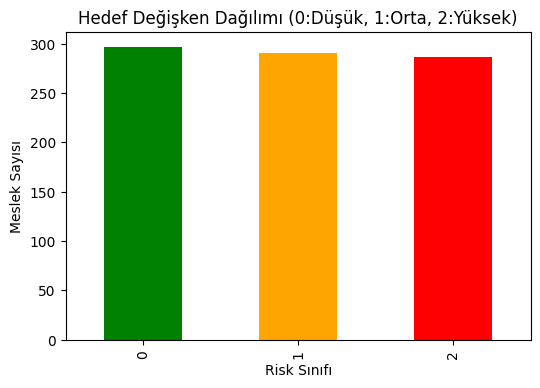

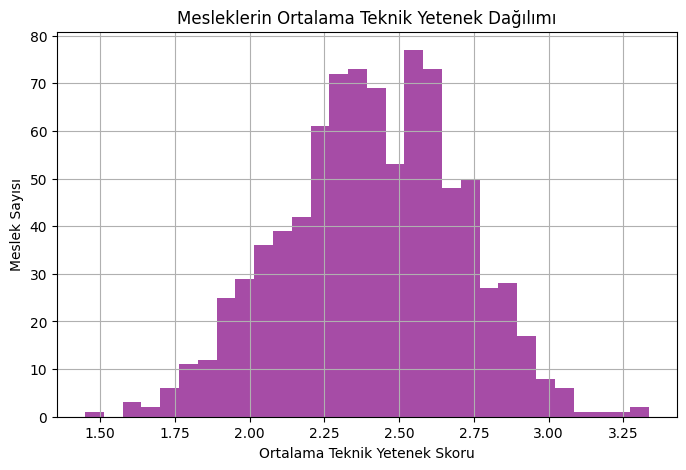

In [ ]:
import seaborn as sns

insani_yetenekler = [
    'Social Perceptiveness', 'Negotiation', 'Persuasion',
    'Service Orientation', 'Complex Problem Solving',
    'Critical Thinking', 'Active Listening', 'Coordination',
    'Instructing', 'Learning Strategies'
]

target_cols = [col for col in insani_yetenekler if col in df_pivot.columns]
df_pivot['Human_Score'] = df_pivot[target_cols].mean(axis=1)

low_th = df_pivot['Human_Score'].quantile(0.33)
high_th = df_pivot['Human_Score'].quantile(0.66)

def get_risk_label(score):
    if score < low_th: return 2
    elif score < high_th: return 1
    else: return 0

df_pivot['AI_risk'] = df_pivot['Human_Score'].apply(get_risk_label)


ignore_cols = ['O*NET-SOC Code', 'occupation', 'Human_Score', 'AI_risk'] + target_cols
tech_cols = [c for c in df_pivot.columns if c not in ignore_cols]

plt.figure(figsize=(6, 4))
df_pivot['AI_risk'].value_counts().sort_index().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title("Hedef Değişken Dağılımı (0:Düşük, 1:Orta, 2:Yüksek)")
plt.xlabel("Risk Sınıfı")
plt.ylabel("Meslek Sayısı")
plt.show()

plt.figure(figsize=(8,5))
df_pivot[tech_cols].mean(axis=1).hist(bins=30, color='purple', alpha=0.7)
plt.title("Mesleklerin Ortalama Teknik Yetenek Dağılımı")
plt.xlabel("Ortalama Teknik Yetenek Skoru")
plt.ylabel("Meslek Sayısı")
plt.show()



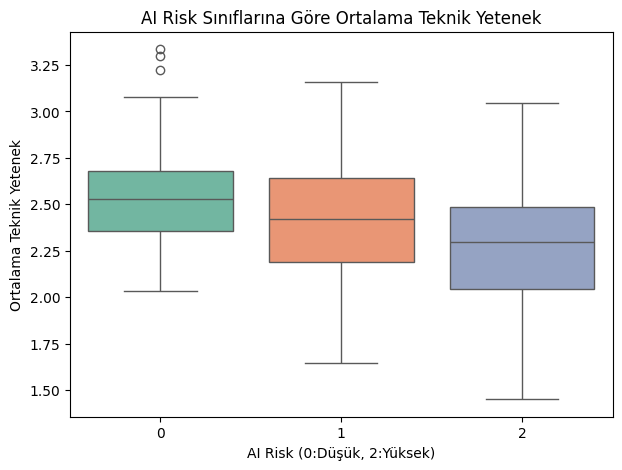

In [ ]:
df_pivot['Avg_Tech_Skill'] = df_pivot[tech_cols].mean(axis=1)

plt.figure(figsize=(7,5))
sns.boxplot(x='AI_risk', y='Avg_Tech_Skill', data=df_pivot, palette="Set2")
plt.title("AI Risk Sınıflarına Göre Ortalama Teknik Yetenek")
plt.xlabel("AI Risk (0:Düşük, 2:Yüksek)")
plt.ylabel("Ortalama Teknik Yetenek")
plt.show()


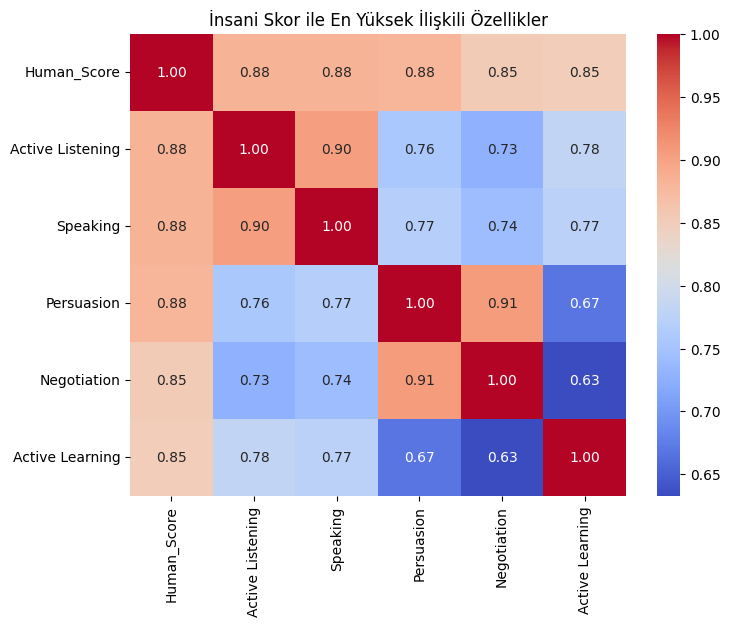

In [ ]:
plt.figure(figsize=(8, 6))

numeric_cols = df_pivot.select_dtypes(include=np.number).columns
corr_matrix = df_pivot[numeric_cols].corr()

top_corr = corr_matrix['Human_Score'].sort_values(ascending=False).head(6)
sns.heatmap(df_pivot[top_corr.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("İnsani Skor ile En Yüksek İlişkili Özellikler")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

cols_to_drop = [
    'O*NET-SOC Code', 'occupation', 'Human_Score', 'AI_risk',
    'Avg_Tech_Skill'
] + target_cols


existing_drops = [c for c in cols_to_drop if c in df_pivot.columns]

X = df_pivot.drop(columns=existing_drops)
y = df_pivot['AI_risk']

print(f"Model Girdileri (X): {X.shape[1]} adet teknik yetenek.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Veri ön işleme tamamlandı. Modellemeye hazır.")

Model Girdileri (X): 25 adet teknik yetenek.
Veri ön işleme tamamlandı. Modellemeye hazır.


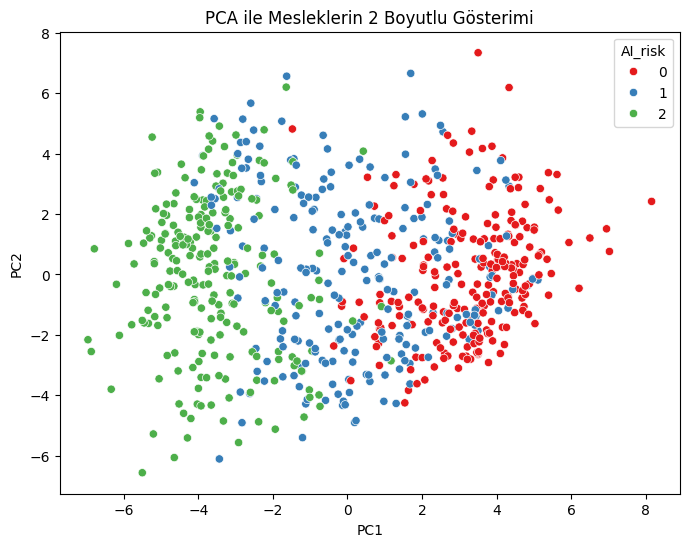

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['AI_risk'] = y_train.values

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='AI_risk',
    palette='Set1'
)
plt.title("PCA ile Mesleklerin 2 Boyutlu Gösterimi")
plt.show()



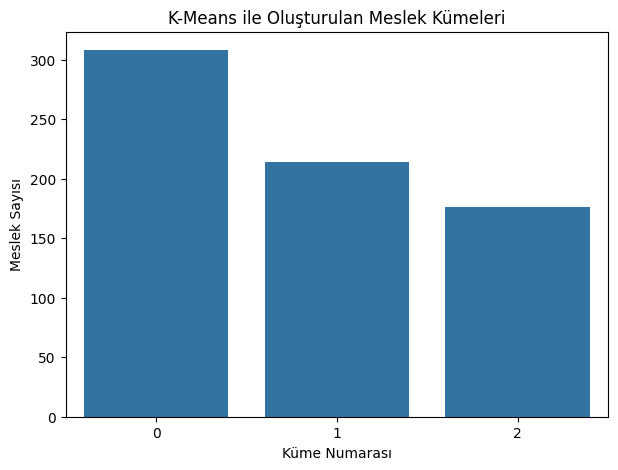


KMeans Küme - AI Risk Karşılaştırması
AI_risk    0   1    2
row_0                
0        216  91    1
1          1  62  151
2         20  79   77


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

plt.figure(figsize=(7,5))
sns.countplot(x=clusters)
plt.title("K-Means ile Oluşturulan Meslek Kümeleri")
plt.xlabel("Küme Numarası")
plt.ylabel("Meslek Sayısı")
plt.show()


print("\nKMeans Küme - AI Risk Karşılaştırması")
print(pd.crosstab(clusters, y_train))



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

print("İlk Model: Lojistik Regresyon")
log_reg = LogisticRegression(max_iter=1000, multi_class='auto')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Lojistik Regresyon Doğruluğu: %{acc_lr*100:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred_lr))

print(f"Temel model %{acc_lr*100:.2f} başarı gösterdi. Daha karmaşık ilişkiler için Random Forest denenecek.")

İlk Model: Lojistik Regresyon
Lojistik Regresyon Doğruluğu: %89.71

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        60
           1       0.83      0.86      0.85        58
           2       0.91      0.93      0.92        57

    accuracy                           0.90       175
   macro avg       0.90      0.90      0.90       175
weighted avg       0.90      0.90      0.90       175

Temel model %89.71 başarı gösterdi. Daha karmaşık ilişkiler için Random Forest denenecek.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Random Forest + Grid Search")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)

grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"\nEn İyi Parametreler: {grid_search.best_params_}")

y_pred_rf = best_rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Optimize Edilmiş Random Forest Doğruluğu: %{acc_rf*100:.2f}")

Random Forest + Grid Search
Fitting 3 folds for each of 12 candidates, totalling 36 fits

En İyi Parametreler: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Optimize Edilmiş Random Forest Doğruluğu: %86.29


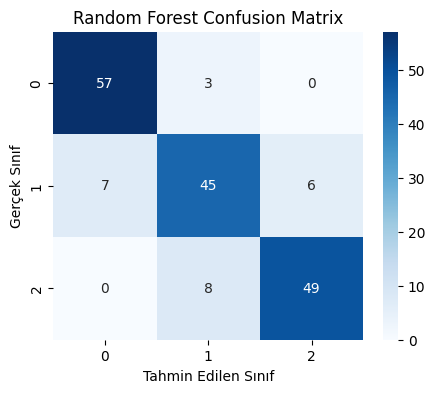


Model Karşılaştırma Tablosu
                      Model  Doğruluk      Fark
0  Lojistik Regresyon (Baz)  0.897143  0.000000
1  Random Forest (Optimize)  0.862857 -0.034286


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.show()

results_df = pd.DataFrame({
    'Model': ['Lojistik Regresyon (Baz)', 'Random Forest (Optimize)'],
    'Doğruluk': [acc_lr, acc_rf],
    'Fark': [0, acc_rf - acc_lr]
})

print("\nModel Karşılaştırma Tablosu")
print(results_df)



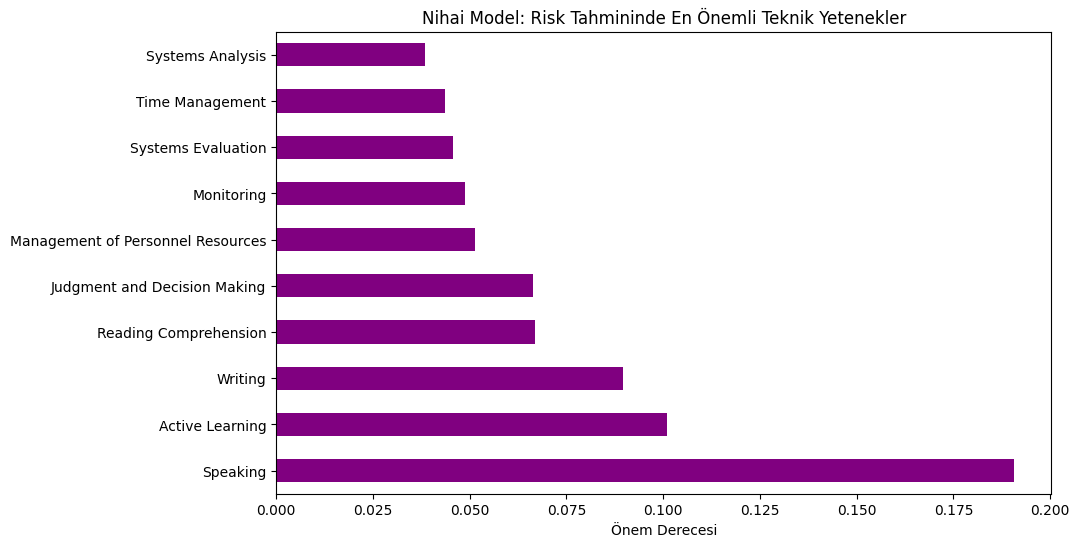


Karar:
Lojistik Regresyon daha basit ve başarılı olduğu için seçilmiştir.


In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='purple')
plt.title("Nihai Model: Risk Tahmininde En Önemli Teknik Yetenekler")
plt.xlabel("Önem Derecesi")
plt.show()

print("\nKarar:")
if acc_rf > acc_lr:
    print("Random Forest modeli, parametre optimizasyonu sonrası daha yüksek başarı gösterdiği için seçilmiştir.")
else:
    print("Lojistik Regresyon daha basit ve başarılı olduğu için seçilmiştir.")

In [ ]:

print("\nEn Düşük AI Riskine Sahip Meslekler:")
print(
    df_pivot.sort_values('Human_Score', ascending=False)
    [['occupation', 'Human_Score']]
    .head(10)
)



En Düşük AI Riskine Sahip Meslekler:
skill                                         occupation  Human_Score
26     Education Administrators, Kindergarten through...        3.989
329                                   Coaches and Scouts        3.988
235    Educational, Guidance, and Career Counselors a...        3.977
389                                        Psychiatrists        3.901
40                        Emergency Management Directors        3.900
246                                               Clergy        3.887
0                                       Chief Executives        3.887
374                 Advanced Practice Psychiatric Nurses        3.875
33                  Medical and Health Services Managers        3.864
395                       Preventive Medicine Physicians        3.862


In [ ]:

print("\nEn Yüksek AI Riskine Sahip Meslekler:")
print(
    df_pivot.sort_values('Human_Score', ascending=True)
    [['occupation', 'Human_Score']]
    .head(10)
)



En Yüksek AI Riskine Sahip Meslekler:
                                            occupation  Human_Score
763  Pressers, Textile, Garment, and Related Materials        1.913
599         Graders and Sorters, Agricultural Products        2.074
732                      Slaughterers and Meat Packers        2.077
539                                             Models        2.100
862                 Cleaners of Vehicles and Equipment        2.138
866                        Packers and Packagers, Hand        2.148
343        Court Reporters and Simultaneous Captioners        2.187
766                 Shoe Machine Operators and Tenders        2.201
594                      Proofreaders and Copy Markers        2.213
865                     Machine Feeders and Offbearers        2.213
